<a href="https://colab.research.google.com/github/shriyaraja/FM-models/blob/main/Lab5_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color=green> Climate, Water, and the Environment

### Lab 5 Week 2 - Oceans and Sea Level

---


In this lab, we will plot sea level rise reconstructions and identify the various contributors (thermal expansion, land ice loss, terrestrial water storage).

We are using data from the following sources:
- ECMWF ERA5 (0.5x0.5 deg) Reanalysis Data: https://climatedataguide.ucar.edu/climate-data/era5-atmospheric-reanalysis, processed using climatereanalyzer.org
- NASA Reconstructed Global Mean Sea Level 1900-2018. Documentation at: https://data.nasa.gov/dataset/reconstructed-global-mean-sea-level-1900-2018-b610f

In [ ]:
#Import required libraries
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import csv
import xarray as xr
import gdown

### Part 1: Plotting sea level rise observations

First, we will read in sea level rise data and global mean temperature change data using Xarray datasets.

Then we will plot the reconstructed contributions to total sea level rise due to thermal expansion and melting ice.

Finally, we will relate these sea level rise contributions to global mean temperature data.

## Read in sea level rise data

In [ ]:

# Google Drive link where the data are stored
drive_link = "https://drive.google.com/uc?id=1Ddu7G_f6m2JC8dwidYLe9LfC6Yxx9kaS"
# Define file name
file_path = "downloaded_data.nc"

# Download the file using gdown
gdown.download(drive_link, file_path, quiet=False)

# Open the dataset
slr_obs = xr.open_dataset(file_path, decode_times=True, decode_coords=False)

# Ensure all of the lines are read properly
clean_attrs = {k: str(v).encode("utf-8", "ignore").decode("utf-8") for k, v in slr_obs.attrs.items()}
slr_obs.attrs = clean_attrs

Downloading...
From: https://drive.google.com/uc?id=1Ddu7G_f6m2JC8dwidYLe9LfC6Yxx9kaS
To: /content/downloaded_data.nc
100%|██████████| 88.4k/88.4k [00:00<00:00, 48.8MB/s]


In [ ]:
slr_obs

<xarray.Dataset> Size: 11kB
Dimensions:                                             (time: 119)
Coordinates:
  * time                                                (time) datetime64[ns] 952B ...
Data variables: (12/21)
    global_average_sea_level_change                     (time) float32 476B ...
    global_average_sea_level_change_upper               (time) float32 476B ...
    global_average_sea_level_change_lower               (time) float32 476B ...
    glac_mean                                           (time) float32 476B ...
    glac_upper                                          (time) float32 476B ...
    glac_lower                                          (time) float32 476B ...
    ...                                                  ...
    global_average_thermosteric_sea_level_change        (time) float32 476B ...
    global_average_thermosteric_sea_level_change_upper  (time) float32 476B ...
    global_average_thermosteric_sea_level_change_lower  (time) float32 476B ...
    sum_of_contrib_processes_mean                       (time) float32 476B ...
    sum_of_contrib_processes_upper                      (time) float32 476B ...
    sum_of_contrib_processes_lower                      (time) float32 476B ...
Attributes: (12/42)
    title:                     Global sea-level changes and contributing proc...
    summary:                   This file contains reconstructed global-mean s...
    id:                        10.5067/GMSLT-FJPL1
    naming_authority:          gov.nasa.jpl
    source:                    Frederikse et al. The causes of sea-level rise...
    project:                   NASA sea-level change science team (N-SLCT)
    ...                        ...
    time_coverage_start:       1900-01-01
    time_coverage_end:         2018-12-31
    time_coverage_duration:    P119Y
    time_coverage_resolution:  P1Y
    date_created:              2020-07-28
    date_modified:             2020-09-14

## Read in temperature data

Here's a function that will read in our global mean temperature data from ECMWF ERA5.

In [ ]:
def read_global_mean_temperature(filename):
    global_mean_temperature = []
    years = []
    with open(filename, 'r') as file:
        csv_reader = csv.reader(file)
        # Assuming the first column contains global mean temperature data
        for _ in range(9):
            next(csv_reader)
        row_count=0
        for row in csv_reader:
            row_count += 1
            if row_count == 85:
                break
            try:
                temperature = float(row[13])  # Assuming the temperature data is numeric
                year = int(row[0])
                global_mean_temperature.append(temperature)
                years.append(year)
            except ValueError:
                # Skip rows that don't contain numeric data
                pass
    return global_mean_temperature,years

Calling the function written above, to read in global mean temperature data from 1940 to 2023. This dataset contains the global-mean annual-mean surface air temperature anomaly (at 2 meter height) relative to the 1951-2000 average.

The function returns two lists: global_mean_temp, which holds the global mean temperature valuees in degrees Celsuis, and years, which holds the calendar year asscoiated with each temperature data point.

In [ ]:
# Define the Google Drive file ID
file_id = "1FQZGjw76QiR_Y9RZwJGpm-THTZwaTlH6"

# Define the output file name
file_path = "global_mean_temp.csv"

# Download the file
gdown.download(f"https://drive.google.com/uc?id={file_id}", file_path, quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1FQZGjw76QiR_Y9RZwJGpm-THTZwaTlH6
To: /content/global_mean_temp.csv
100%|██████████| 18.6k/18.6k [00:00<00:00, 26.5MB/s]


'global_mean_temp.csv'

In [ ]:
global_mean_temp = []
years = []
global_mean_temp, years = read_global_mean_temperature("global_mean_temp.csv")

# Comparing global mean sea level and temperature

Now that we've loaded these datasets,let's plot them together.

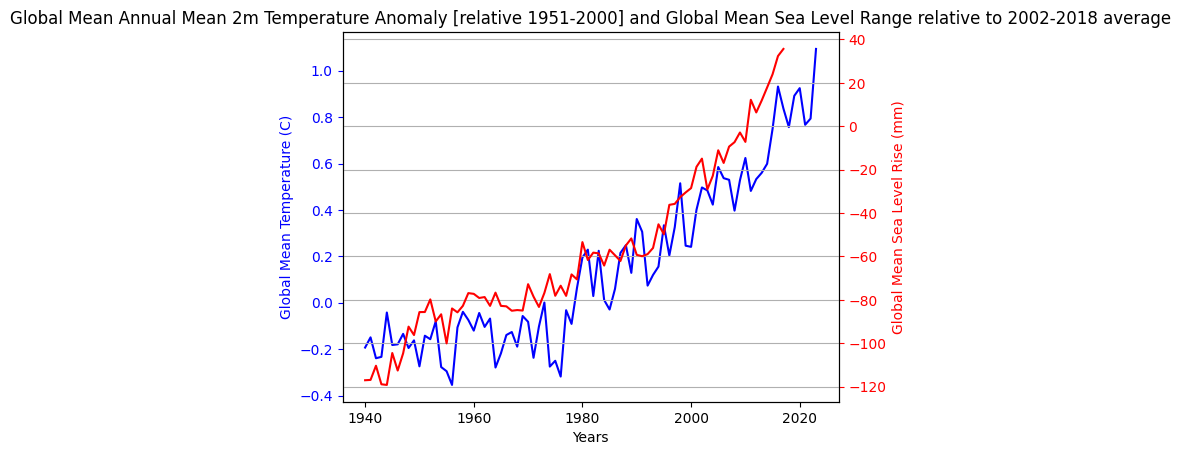

In [ ]:
fig, ax1 = plt.subplots()

# Plotting the first line
ax1.plot(years, global_mean_temp, color='blue')
ax1.set_xlabel('Years')
ax1.set_ylabel('Global Mean Temperature (C)', color='blue')
ax1.tick_params('y', colors='blue')

# Creating a second y-axis
ax2 = ax1.twinx()

# Plotting the second line (assuming 'slr' is defined)
ax2.plot(years[0:78], slr_obs.global_average_sea_level_change.sel(time=slice('1941', '2018')), color='red')
ax2.set_ylabel('Global Mean Sea Level Rise (mm)', color='red')
ax2.tick_params('y', colors='red')

plt.title('Global Mean Annual Mean 2m Temperature Anomaly [relative 1951-2000] and Global Mean Sea Level Range relative to 2002-2018 average')
plt.grid(True)
plt.show()

How much has global mean air temperature changed since 1940?<br>
How much has global mean sea level changed since 1940? <br>
What is the rate in mm per year?

# Contributions to sea level rise

Now let's look at the global sea level dataset, and separate out the various components that contribute to sea level rise:

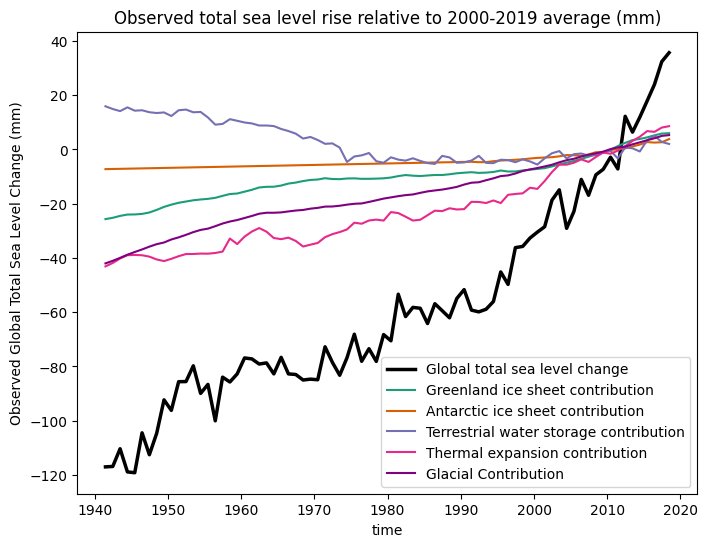

In [ ]:
import matplotlib.pyplot as plt

# Define custom colors for different contributors
colors = {
    "Greenland": "#1b9e77",  # Teal green
    "Antarctic": "#d95f02",  # Burnt orange
    "Terrestrial Water Storage": "#7570b3",  # Deep purple-blue
    "Thermal Expansion": "#e7298a",  # Magenta-pink
    'Glacial': 'purple'
}

# Create the figure and axis
fig = plt.figure(figsize=[8, 6])
ax = fig.add_subplot(1, 1, 1)

# Plot total sea level change in black and thick
slr_obs.global_average_sea_level_change.sel(time=slice("1941", "2018")).plot.line(
    ax=ax, label="Global total sea level change", linewidth=2.5, color="black"
)

# Plot contributors in custom colors
slr_obs.GrIS_mean.sel(time=slice("1941", "2018")).plot.line(
    ax=ax, label="Greenland ice sheet contribution", color=colors["Greenland"]
)
slr_obs.AIS_mean.sel(time=slice("1941", "2018")).plot.line(
    ax=ax, label="Antarctic ice sheet contribution", color=colors["Antarctic"]
)
slr_obs.tws_mean.sel(time=slice("1941", "2018")).plot.line(
    ax=ax, label="Terrestrial water storage contribution", color=colors["Terrestrial Water Storage"]
)
slr_obs.global_average_thermosteric_sea_level_change.sel(time=slice("1941", "2018")).plot.line(
    ax=ax, label="Thermal expansion contribution", color=colors["Thermal Expansion"]
)
slr_obs.glac_mean.sel(time=slice("1941", "2018")).plot.line(
    ax=ax, label="Glacial Contribution", color=colors["Glacial"]
)

# Formatting
plt.title("Observed total sea level rise relative to 2000-2019 average (mm)")
ax.set_ylabel("Observed Global Total Sea Level Change (mm)")
ax.legend()
plt.show()

# <font color=red weight=bold> Stop and discuss in class!

<div style="display: flex; align-items: center; justify-content: center;">
  <img src="https://m.media-amazon.com/images/I/61gDDm3btfL._SL1000_.jpg" alt="Stop Sign" width="400"">
</div>



### Part 2: Now we want to relate global mean temperature to these different sea level rise contributors
Which processes that contribute to sea level rise do you think are more or less sensitive to global mean temperature?

 <font color=blue> Make some guesses before we quantify this.

We can use linear regression to quantify the relationship between global mean temperature and a specific process contributing to sea level. The code below fits a line through observations of sea level rise due to land ice loss between 1941 and 2018 and our global-mean temperature data over the same time period and returns the slope and intercept of that line.

In [ ]:
temp = np.array(global_mean_temp[:78]) # this selects global-mean temperature data over the same time period

First, I've added the contribution to sea level rise from Antarctic and Greenland ice sheet melt to produce a variable containing total sea level rise from land ice loss from 1941-2018.

In [ ]:
land_ice_loss = slr_obs.GrIS_mean.sel(time=slice('1941', '2018'))+slr_obs.AIS_mean.sel(time=slice('1941', '2018'))







Now let's plot land ice loss (in terms of its sea level change) against global mean temperature at each time, and estimate a linear fit and $R^{2}$ metric for goodness of fit

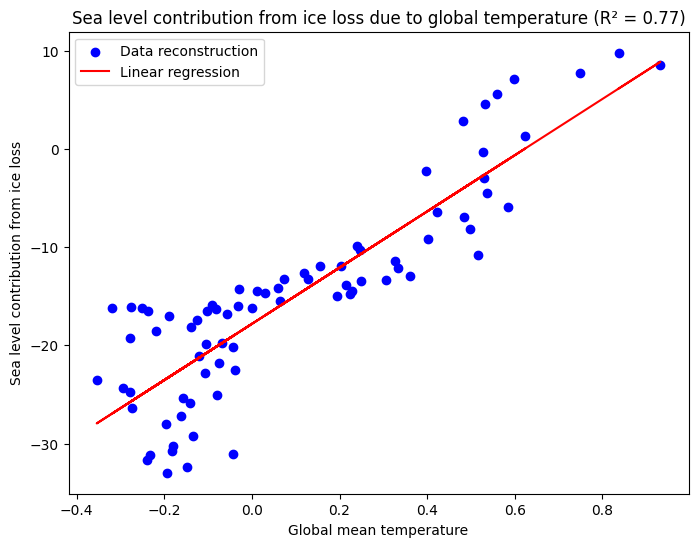

In [ ]:
slr_ice_loss_obs = np.array(land_ice_loss.data)
slope, intercept = np.polyfit(temp, slr_ice_loss_obs, 1)
# use this linear regression to calculate predicted thermosteric sea level rise given some temp increase
slr_ice_loss_predicted = slope * temp + intercept

# Calculate R-squared
ss_res = np.sum((slr_ice_loss_obs - slr_ice_loss_predicted) ** 2)
ss_tot = np.sum((slr_ice_loss_obs - np.mean(slr_ice_loss_obs)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

# Make a scatter plot and add the regression line
plt.figure(figsize=(8, 6))
plt.scatter(temp, slr_ice_loss_obs, color='blue', label='Data reconstruction')
plt.plot(temp, slr_ice_loss_predicted, color='red', label='Linear regression')
plt.xlabel('Global mean temperature')
plt.ylabel('Sea level contribution from ice loss')
plt.title(f'Sea level contribution from ice loss due to global temperature (R² = {r_squared:.2f})')
plt.legend()
plt.show()

<font color=orange> Now it's your turn: plot **thermosteric** sea level change against global mean temperature, and calculate the linear fit for this term.

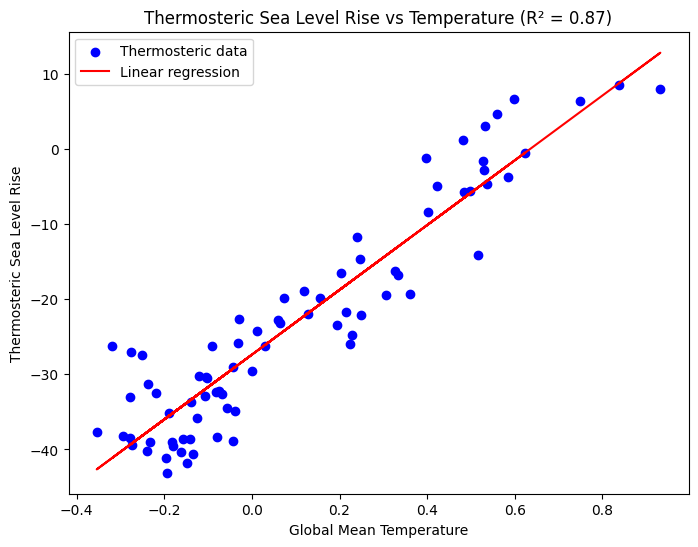

In [ ]:
# calculate linear fit
thermosteric_data = slr_obs.global_average_thermosteric_sea_level_change.sel(time=slice('1941', '2018'))
slr_thermosteric_obs = np.array(thermosteric_data.data)
temp = temp[:len(slr_thermosteric_obs)]
slope, intercept = np.polyfit(temp, slr_thermosteric_obs, 1)
# use this linear regression to calculate predicted thermosteric sea level rise given some temp increase
slr_thermosteric_predicted = slope * temp + intercept
# Calculate R-squared
ss_res = np.sum((slr_thermosteric_obs - slr_thermosteric_predicted) ** 2)
ss_tot = np.sum((slr_thermosteric_obs - np.mean(slr_thermosteric_obs)) ** 2)
r_squared = 1 - (ss_res / ss_tot)
# Make a scatter plot and add the regression line
plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(temp, slr_thermosteric_obs, color='blue', label='Thermosteric data')

# Regression line
plt.plot(temp, slr_thermosteric_predicted, color='red', label='Linear regression')

# Labels and title
plt.xlabel('Global Mean Temperature')
plt.ylabel('Thermosteric Sea Level Rise')
plt.title(f'Thermosteric Sea Level Rise vs Temperature (R² = {r_squared:.2f})')

plt.legend()
plt.show()


<font color=orange> Now plot **terrestrial land storage** contribution to sea level change against global mean temperature, and calculate the linear fit for this term.

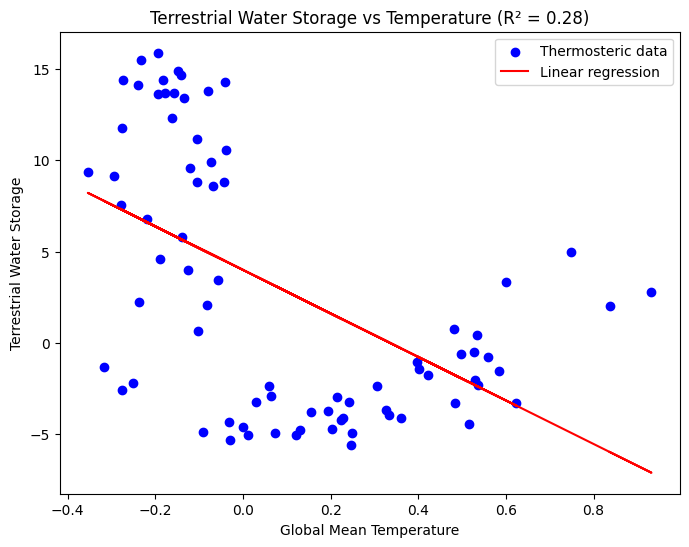

In [ ]:
# calculate linear fit
terrestrial_data = slr_obs.tws_mean.sel(time=slice("1941", "2018"))
slr_terrestrial_obs = np.array(terrestrial_data.data)
temp = temp[:len(slr_terrestrial_obs)]
slope, intercept = np.polyfit(temp, slr_terrestrial_obs, 1)
# use this linear regression to calculate predicted thermosteric sea level rise given some temp increase
slr_terrestrial_predicted = slope * temp + intercept
# Calculate R-squared
ss_res = np.sum((slr_terrestrial_obs - slr_terrestrial_predicted) ** 2)
ss_tot = np.sum((slr_terrestrial_obs - np.mean(slr_terrestrial_obs)) ** 2)
r_squared = 1 - (ss_res / ss_tot)
# Make a scatter plot and add the regression line
plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(temp, slr_terrestrial_obs, color='blue', label='Thermosteric data')

# Regression line
plt.plot(temp, slr_terrestrial_predicted, color='red', label='Linear regression')

# Labels and title
plt.xlabel('Global Mean Temperature')
plt.ylabel('Terrestrial Water Storage')
plt.title(f'Terrestrial Water Storage vs Temperature (R² = {r_squared:.2f})')

plt.legend()
plt.show()


<font color=orange> And just for fun, an exta (optional) challenge: can you **separate out the land ice contributions from Antarctica versus Greenland ice sheets**? Compare the linear fits against global mean temperature, respectively. Are they similar or different?

<font color=orange>  *Hint: look at how we isolated the 'land_ice_loss' term earlier.*

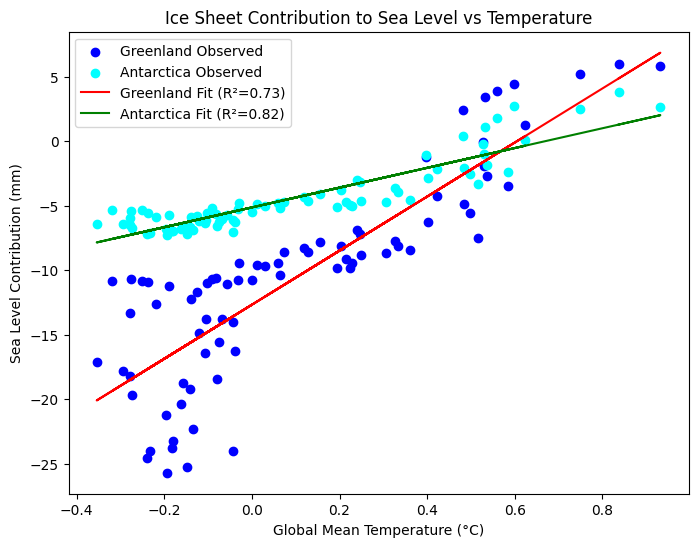

In [ ]:
# calculate linear fit
land_ice_gr = slr_obs.GrIS_mean.sel(time=slice("1941", "2018"))
land_ice_id = slr_obs.AIS_mean.sel(time=slice("1941", "2018"))
slr_gr_obs = np.array(land_ice_gr.data)
slr_id_obs = np.array(land_ice_id.data)
temp = temp[:len(slr_gr_obs)]

slope, intercept = np.polyfit(temp, slr_gr_obs, 1)
slr_gr_predicted = slope * temp + intercept

slope, intercept = np.polyfit(temp, slr_id_obs, 1)
slr_id_predicted = slope * temp + intercept

# Calculate R-squared
ss_res_gr = np.sum((slr_gr_obs - slr_gr_predicted) ** 2)
ss_tot_gr = np.sum((slr_gr_obs - np.mean(slr_gr_obs)) ** 2)
r_squared_gr = 1 - (ss_res_gr / ss_tot_gr)

ss_res_id = np.sum((slr_id_obs - slr_id_predicted) ** 2)
ss_tot_id = np.sum((slr_id_obs - np.mean(slr_id_obs)) ** 2)
r_squared_id = 1 - (ss_res_id / ss_tot_id)
# Make a scatter plot and add the regression line
plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(temp, slr_gr_obs, color='blue', label='Greenland Observed')
plt.scatter(temp, slr_id_obs, color='cyan', label='Antarctica Observed')

# Regression line
plt.plot(temp, slr_gr_predicted, color='red', label=f'Greenland Fit (R²={r_squared_gr:.2f})')
plt.plot(temp, slr_id_predicted, color='green', label=f'Antarctica Fit (R²={r_squared_id:.2f})')

# Labels and title
plt.xlabel('Global Mean Temperature (°C)')
plt.ylabel('Sea Level Contribution (mm)')
plt.title('Ice Sheet Contribution to Sea Level vs Temperature')

plt.legend()
plt.show()